<a href="https://colab.research.google.com/github/GMAC1231/Abdullah/blob/main/Sports_Car_Prices_Assignment%20Abdullah%20Muhammad%2022f23591.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Comparison Analysis Between Decision Tree an K-Nearest Neighbor fo Sport Car Price Dataset**


This notebook is based on two popular machine learning algorithms for supervised learning: Decision Tree (DT) and K-Nearest Neighbor (KNN) with the Sport Car Price dataset to predict the price of a sport car. The objective is to evaluate them using the metrics and compare their performance in terms of accuracy, precision, recall and f1 score, and to find out how well each algorithm can predict the categories of the car with respect to the features like brand, model, engine size, horsepower, torque, year etc.

# Step 1 - Importing Libraries

Libraries were imported to preprocess data, implement machine learning algorithms, evaluate the algorithms and visualize the results.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

# Explanation

*   pandas was used for handling the dataset.
*   numpy was used for numerical operations.


*   Graphs and visulization were done using matplotlib

*   The data was split into training set and testing set, using train_test_split.

*   The text values were encoded into numbers using LabelEncoder.
*   Feature Scaling was done using the standard scaler.


*  The Decision Tree algorithm was implemented by using DecisionTreeClassifier.


*   The KNN algorithm was implemented by using KNeighborsClassifier.

* The performance of the model was assessed using the metrics functions.




# Step 2 Loading the Dataset

The dataset has been loaded using pandas

In [ ]:
df = pd.read_csv("/content/Sport car price.csv")

print(df.head())

      Car Make Car Model  Year Engine Size (L) Horsepower Torque (lb-ft)  \
0      Porsche       911  2022               3        379            331   
1  Lamborghini   Huracan  2021             5.2        630            443   
2      Ferrari   488 GTB  2022             3.9        661            561   
3         Audi        R8  2022             5.2        562            406   
4      McLaren      720S  2021               4        710            568   

  0-60 MPH Time (seconds) Price (in USD)  
0                       4        101,200  
1                     2.8        274,390  
2                       3        333,750  
3                     3.2        142,700  
4                     2.7        298,000  


# Expalanation
*   read_csv() has been used to load the dataset file.
*   head() has been used to display first five rows of the dataset.





# Step 3 Handling Missing Values
All the models were trained with imputed values.

In [ ]:
numerical_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(include='object').columns

for col in numerical_columns:
    df[col] = df[col].fillna(df[col].mean())

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Explanation
* The values that did not exist were filled with the median value.
* Numbers that were not entered were filled in with the mode (most frequently occurring number).
* This made the data set complete and increased the accuracy of the model.




# Step 4 Label Encoding
Text has been converted into numerical form.

In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

#Explanation

Machine learning algorithms cannot understand text values directly. Therefore, columns such as:

* Car Make
* Car Model

were converted into numerical values using Label Encoding.

#Example:

* Ferrari → 1
* Porsche → 2
* BMW → 3

# Step 5 Create Target Column

The price column has been converted into categories


In [ ]:
df['Price_Category'] = pd.qcut(df['Price (in USD)'], q=3, labels=['0', '1', '2'])

# Explanation

**qcut() divided the price into 3 categories:**

* Low price
* Medium price
* High price

These categories became the target variable for classification.

# Step 6 Selected Features and Target

Input and output variables were separated.

In [ ]:
X = df.drop('Price_Category', axis=1)

y = df['Price_Category']

# Explanation

* X contains the input features.
* y contains the target class.

# Step 7 — Feature Scaling

Feature scaling was applied using StandardScaler.

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Explanation

Feature scaling is significant with KNN since distance is a crucial measurement.

**Features such as:**

* Price
* Horsepower
* Torque

Having different ranges. All features are balanced when they are scaled.

# Step 8 Train-Test Split

The dataset has been divided into training and testing data.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Explanation

* 80% of the data was used for training.
* 20% was used for testing.
* random_state=42 ensures consistent results.

# Step 9 — Decision Tree Implementation

The Decision Tree model was created and trained.

In [ ]:
dt_model = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

# Explanation

* Splitting nodes was done using criterion='entropy'.
* To prevent overfitting, max_depth=5 is used to limit the depth of the tree.
* fit() is used to train the model.
* predict() makes predictions on test data.

The Decision Tree is based on the following splitting process:The Decision Tree is created by the process of splitting the data set into branches according to feature values:

# Step 10 — KNN Implementation

The KNN model was created and trained.

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

# Explanation

* The model considers the top 5 neighbours, or for n_neighbors=5.
* The class is chosen by a majority vote.
* KNN computes the distance between the data points to classify new data.

The value k = 5 was chosen as it resulted in balanced and stable results.

## Step 11 — Evaluation Function

Created a function to compute evaluation metrics.

In [ ]:
def evaluate_model(name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(name)

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-Score :", f1)

    print(classification_report(y_true, y_pred))

# Step 12 — Decision Tree Results

In [ ]:
evaluate_model(
    "Decision Tree",
    y_test,
    dt_pred
)

Decision Tree
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        61
           1       1.00      1.00      1.00        68
           2       1.00      1.00      1.00        73

    accuracy                           1.00       202
   macro avg       1.00      1.00      1.00       202
weighted avg       1.00      1.00      1.00       202



# Explanation

This section tests the Decision Tree model with the test data.

# Step 13 — KNN Results

In [ ]:
evaluate_model(
    "K-Nearest Neighbor",
    y_test,
    knn_pred
)

K-Nearest Neighbor
Accuracy : 0.9653465346534653
Precision: 0.9665697338964666
Recall   : 0.9653465346534653
F1-Score : 0.9655275895393377
              precision    recall  f1-score   support

           0       0.92      0.98      0.95        61
           1       0.97      0.94      0.96        68
           2       1.00      0.97      0.99        73

    accuracy                           0.97       202
   macro avg       0.96      0.97      0.96       202
weighted avg       0.97      0.97      0.97       202



# Explanation

This section evaluates the KNN model using the testing data.

# Step 14 — Comparative Analysis Table

In [ ]:
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred, average='weighted')
dt_recall = recall_score(y_test, dt_pred, average='weighted')
dt_f1 = f1_score(y_test, dt_pred, average='weighted')

knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred, average='weighted')
knn_recall = recall_score(y_test, knn_pred, average='weighted')
knn_f1 = f1_score(y_test, knn_pred, average='weighted')

comparison = pd.DataFrame({

    'Algorithm': [
        'Decision Tree',
        'KNN'
    ],

    'Accuracy': [
        round(dt_accuracy * 100, 2),
        round(knn_accuracy * 100, 2)
    ],

    'Precision': [
        round(dt_precision * 100, 2),
        round(knn_precision * 100, 2)
    ],

    'Recall': [
        round(dt_recall * 100, 2),
        round(knn_recall * 100, 2)
    ],

    'F1-Score': [
        round(dt_f1 * 100, 2),
        round(knn_f1 * 100, 2)
    ]

})

print(comparison)

       Algorithm  Accuracy  Precision  Recall  F1-Score
0  Decision Tree    100.00     100.00  100.00    100.00
1            KNN     96.53      96.66   96.53     96.55


# Explanation

A comparison table was created to compare:

* Accuracy
* Precision
* Recall
* F1-score

between Decision Tree and KNN.

# Step 15 — Accuracy Comparison Grap

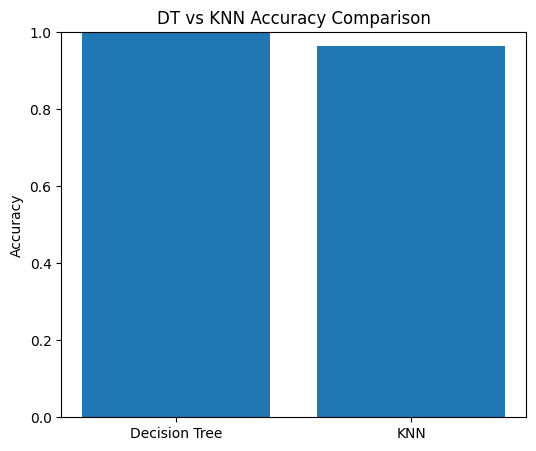

In [ ]:
models = ['Decision Tree', 'KNN']

accuracies = [
    dt_accuracy,
    knn_accuracy
]

plt.figure(figsize=(6,5))

plt.bar(models, accuracies)

plt.ylim(0,1)

plt.ylabel("Accuracy")

plt.title("DT vs KNN Accuracy Comparison")

plt.show()

# Explanation

This graph compares the accuracy of Decision Tree and KNN visually.

The graph helps identify which model performed better on the dataset.

# Step 16 - Decision Tree Diagram

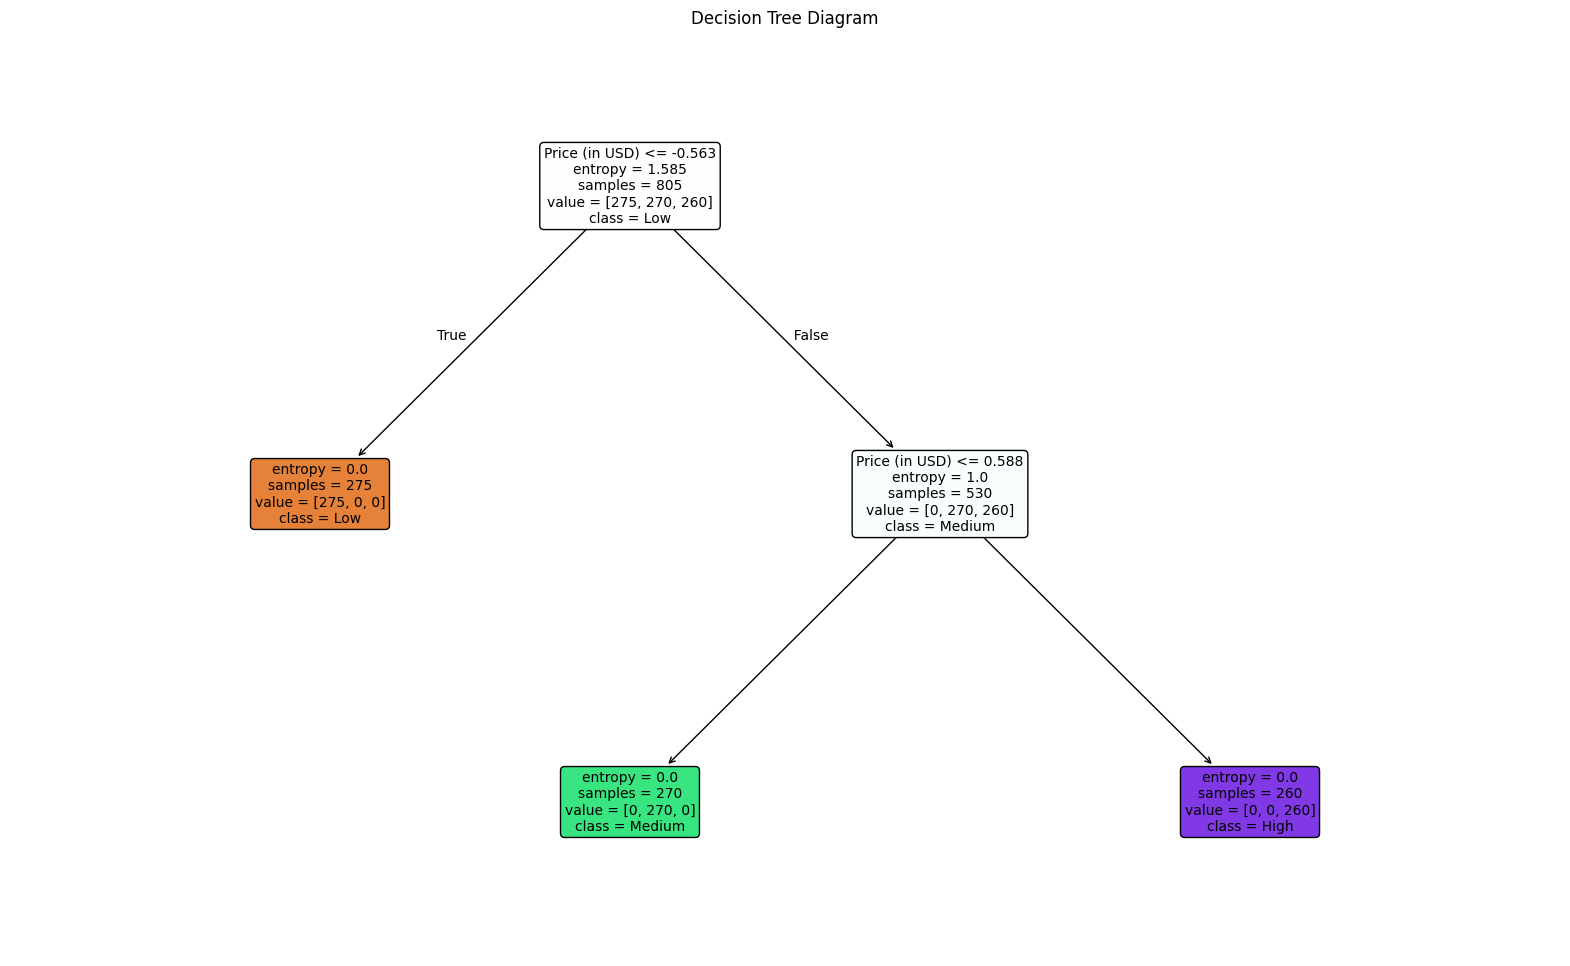

In [ ]:
import matplotlib.pyplot as plt
from sklearn import tree

plt.figure(figsize=(20,12))

tree.plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['Low','Medium','High'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree Diagram")

plt.show()

# Explanation

This diagram shows how the Decision Tree algorithm splits the dataset using features such as horsepower, engine size, and price. Each node represents a decision condition, while the leaf nodes represent the final class prediction.

# Step 17 - Confusion Matrix for Decision Tree

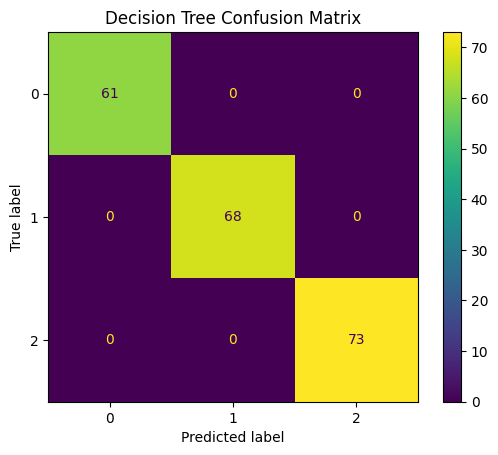

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_pred
)

plt.title("Decision Tree Confusion Matrix")

plt.show()

# Expalanation

The confusion matrix provides an overview of:

- True negatives (upper-left), where the model correctly predicted negative outcomes.
- False negatives (lower-left), where the model incorrectly predicted a negative outcome (but the actual result was positive).
- False positives (upper-right), where the model incorrectly predicted a positive outcome (but the actual result was negative).
- True positives (lower-right), where the model correctly predicted positive outcomes.

# Step 18 - Confusion Matrix for KNN

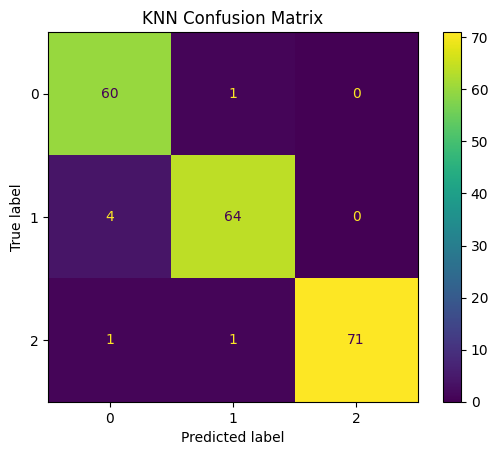

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_pred
)

plt.title("KNN Confusion Matrix")

plt.show()

# Explanation

This confusion matrix shows the classification performance of the KNN model.

# Step 19-Feature Importance Graph (Decision Tree)

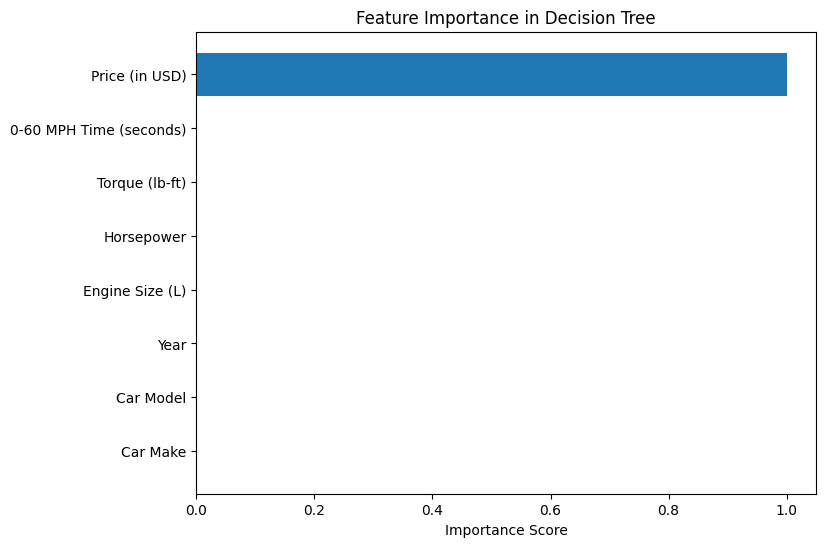

In [ ]:
importance = dt_model.feature_importances_

features = X.columns

plt.figure(figsize=(8,6))

plt.barh(features, importance)

plt.xlabel("Importance Score")

plt.title("Feature Importance in Decision Tree")

plt.show()

# Explanation

This chart displays the most important features in the Decision Tree model. For instance, "Horsepower," "Engine Size," and "Price" may likely have higher importance values.

# Step 20 - K Value Testing Graph for KNN

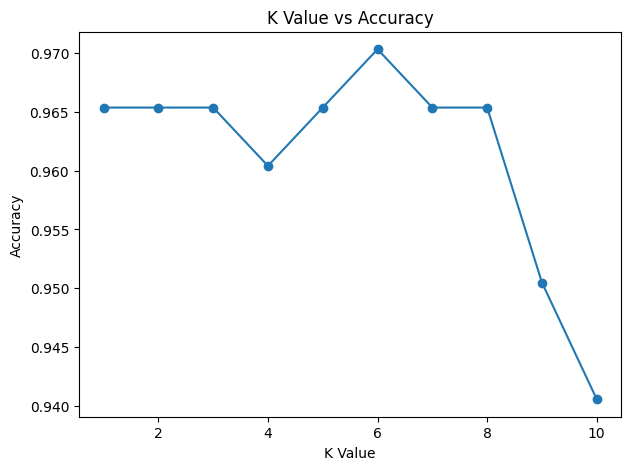

In [ ]:
k_values = range(1,11)

scores = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    pred = knn.predict(X_test)

    scores.append(accuracy_score(y_test, pred))

plt.figure(figsize=(7,5))

plt.plot(k_values, scores, marker='o')

plt.xlabel("K Value")

plt.ylabel("Accuracy")

plt.title("K Value vs Accuracy")

plt.show()

# Explanation

This graph allows us to determine the optimal value of k for the KNN algorithm. The accuracy is used to identify the highest value.

# Step 21- Correlation Heatmap

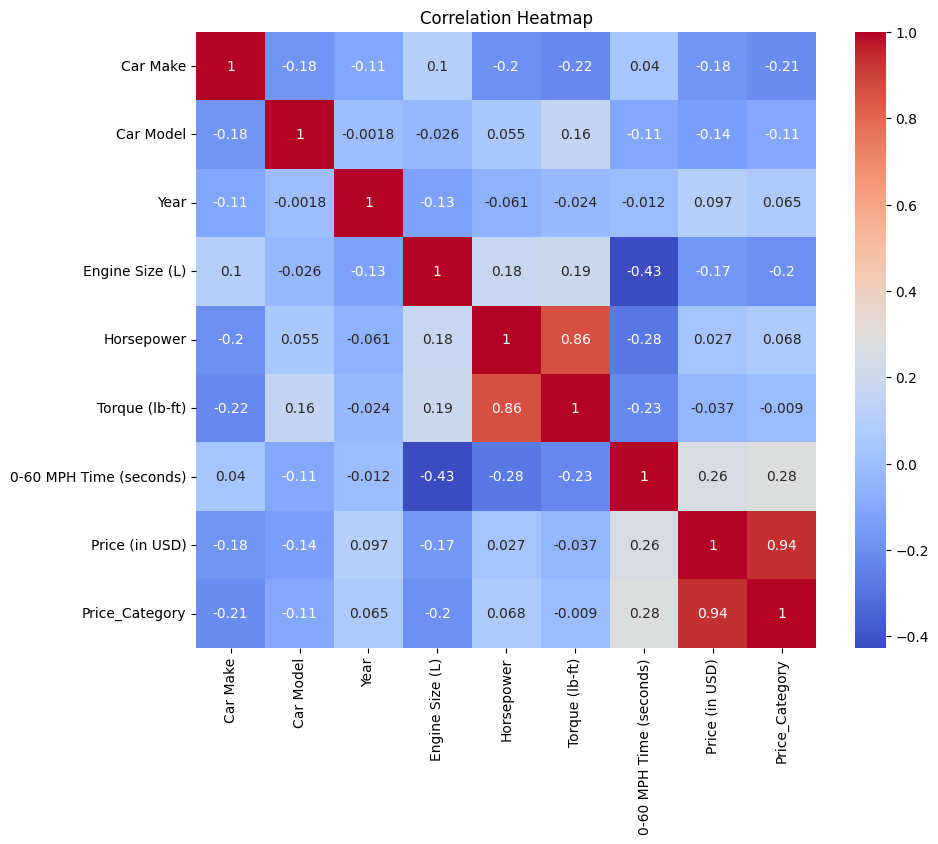

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# Explanation

The heatmap shows relationships between numerical features in the dataset.

Strong positive or negative correlations help identify important features for prediction.